# Task 2 — Feature Extraction with DINOv3

## Parameters

In [1]:
import os

# HuggingFace token (set HF_TOKEN env var before launching Jupyter)
HF_TOKEN = os.getenv("HF_TOKEN")

MODEL_ID   = "facebook/dinov3-vitb16-pretrain-lvd1689m"  # ViT-B/16
PATCH_SIZE = 16       # default patch size for ViT-B/16

# Which transformer block to extract embeddings from.
# ViT-B has 12 blocks (0–11). hidden_states indexing:
#   0 = patch embedding layer output
#   1–12 = after each transformer block
LAYER_IDX  = 9        # block 8 output (0-indexed after patch embed)

# Input image scale factor applied before feeding to the model.
#   1.0  = original resolution
#   2.0  = upsample 2x (more patches, finer spatial detail)
#   0.5  = downsample 2x (fewer patches, larger receptive field per patch)
IMG_SCALE  = 1

# Center crop settings (applied after IMG_SCALE, before the model).
#   CENTER_CROP = False  → use the full (scaled) image
#   CENTER_CROP = True   → crop a square of CROP_SIZE × CROP_SIZE from the center
CENTER_CROP = True
CROP_SIZE   = 224   

# Data — must match a cached .npy file in ../data/
DATASET    = "jrc_mus-liver" # e.g. jrc_hela-3, jrc_cos7-11, jrc_mus-kidney, jrc_mus-liver
SCALE      = "s3"
N_SLICES   = 10
SLICE_IDX  = 6        # which slice to use for patch PCA visualization

## Imports

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel

# Local utilities (shared across task notebooks)
import sys
sys.path.insert(0, str(Path("../shared").resolve()))
from utils import (
    normalize_uint8, em_to_rgb, pad_to_patch_multiple, center_crop,
    zscore, get_embeddings, upsample_patch_embeddings,
    minmax, make_overlay, prepare_mito_for_input,
)

/home/carsen/anaconda3/envs/emseg/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Load DINOv3 model

In [3]:
print(f"Loading model: {MODEL_ID}")
processor = AutoImageProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model     = AutoModel.from_pretrained(MODEL_ID, token=HF_TOKEN)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)
print(f"Device : {device}")
print(f"Patch size : {PATCH_SIZE}")
print(f"Embedding layer index : {LAYER_IDX}  (0=patch embed, 1-12=transformer blocks)")

Loading model: facebook/dinov3-vitb16-pretrain-lvd1689m


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Device : cpu
Patch size : 16
Embedding layer index : 9  (0=patch embed, 1-12=transformer blocks)


## Load EM slices

In [4]:
DATA_DIR  = Path("../data/raw")
em_path   = DATA_DIR / f"{DATASET}_em_{SCALE}_{N_SLICES}slices.npy"
mito_path = DATA_DIR / f"{DATASET}_mito_{SCALE}_{N_SLICES}slices.npy"

if not em_path.exists():
    raise FileNotFoundError(
        f"{em_path} not found. Run the Task 1 notebook first to download the data."
    )

em = np.load(em_path)
print(f"Loaded EM  : {em_path}  shape={em.shape}  dtype={em.dtype}")

# Auto-adjust CROP_SIZE so it never exceeds the scaled image dimensions
if CENTER_CROP:
    scaled_h = max(1, round(em.shape[1] * IMG_SCALE))
    scaled_w = max(1, round(em.shape[2] * IMG_SCALE))
    CROP_SIZE = min(CROP_SIZE, scaled_h, scaled_w)
    print(f"CROP_SIZE adjusted to {CROP_SIZE}  (scaled image: {scaled_h}×{scaled_w} px)")

if mito_path.exists():
    mito = np.load(mito_path)
    print(f"Loaded mito: {mito_path}  shape={mito.shape}  dtype={mito.dtype}")
else:
    mito = None
    print("Mito mask not found — overlay row will be skipped.")

Loaded EM  : ../data/raw/jrc_mus-liver_em_s3_10slices.npy  shape=(10, 1591, 1593)  dtype=uint8
CROP_SIZE adjusted to 224  (scaled image: 1591×1593 px)
Loaded mito: ../data/raw/jrc_mus-liver_mito_s3_10slices.npy  shape=(10, 795, 796)  dtype=uint32


## Helper functions

In [5]:
# Bind notebook-level parameters into convenience wrappers
NUM_REGISTER_TOKENS = model.config.num_register_tokens

def _em_to_rgb(slice_2d):
    return em_to_rgb(slice_2d, scale=IMG_SCALE,
                     center_crop_size=CROP_SIZE if CENTER_CROP else None)

def _get_embeddings(pil_img):
    return get_embeddings(pil_img, model, processor, device,
                          PATCH_SIZE, LAYER_IDX, NUM_REGISTER_TOKENS)

def _prepare_mito(mito_slice, em_slice):
    return prepare_mito_for_input(mito_slice, em_slice, scale=IMG_SCALE,
                                  center_crop_size=CROP_SIZE if CENTER_CROP else None)

## Extract embeddings for all slices

In [6]:
cls_tokens  = []
patch_grids = []

for i, sl in enumerate(em):
    img = _em_to_rgb(sl)
    cls, patches = _get_embeddings(img)
    cls_tokens.append(cls)
    patch_grids.append(patches)
    print(f"  slice {i}: cls={cls.shape}  patches={patches.shape}")

cls_tokens = np.stack(cls_tokens, axis=0)
print(f"\nAll CLS tokens   : {cls_tokens.shape}")
print(f"Patch grid shape : {patch_grids[0].shape}  (nh, nw, D)")

  slice 0: cls=(768,)  patches=(14, 14, 768)


  slice 1: cls=(768,)  patches=(14, 14, 768)


  slice 2: cls=(768,)  patches=(14, 14, 768)


  slice 3: cls=(768,)  patches=(14, 14, 768)


  slice 4: cls=(768,)  patches=(14, 14, 768)


  slice 5: cls=(768,)  patches=(14, 14, 768)


  slice 6: cls=(768,)  patches=(14, 14, 768)
  slice 7: cls=(768,)  patches=(14, 14, 768)


  slice 8: cls=(768,)  patches=(14, 14, 768)


  slice 9: cls=(768,)  patches=(14, 14, 768)

All CLS tokens   : (10, 768)
Patch grid shape : (14, 14, 768)  (nh, nw, D)


## Sanity check 1 — PCA of patch embeddings

Patch PCA explained variance (PC1-3): [0.098 0.08  0.049]


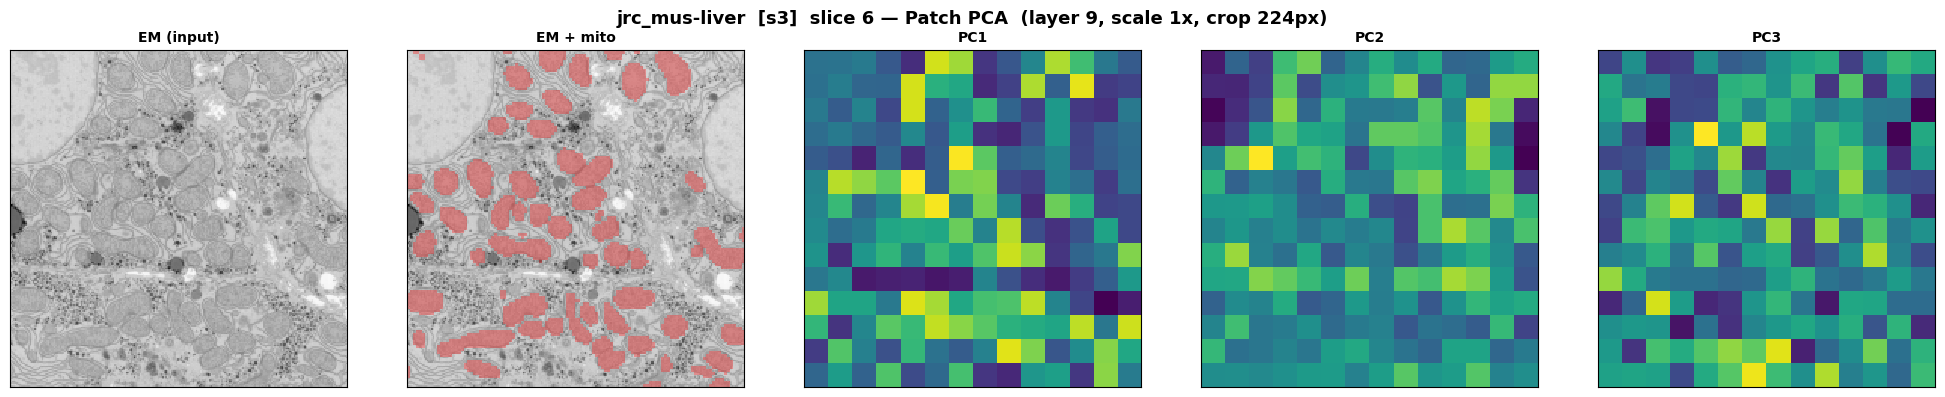

Figure saved to ../outputs/task2/task2_patch_pca_jrc_mus-liver_s3_slice6_layer9_scale1_crop224.png


In [7]:
pca = PCA(n_components=3)
pca.fit(np.concatenate([pg.reshape(-1, pg.shape[-1]) for pg in patch_grids]))
print(f"Patch PCA explained variance (PC1-3): {pca.explained_variance_ratio_.round(3)}")

pg = patch_grids[SLICE_IDX]
nh, nw, D = pg.shape
proj   = pca.transform(pg.reshape(-1, D))
pc_maps = [minmax(proj[:, c]).reshape(nh, nw) for c in range(3)]

model_input = np.array(_em_to_rgb(em[SLICE_IDX]))

row_images = [model_input];  row_labels = ["EM (input)"];  row_cmaps = [None]
if mito is not None:
    row_images.append(make_overlay(model_input, _prepare_mito(mito[SLICE_IDX], em[SLICE_IDX])))
    row_labels.append("EM + mito");  row_cmaps.append(None)
for c in range(3):
    row_images.append(pc_maps[c]);  row_labels.append(f"PC{c+1}");  row_cmaps.append("viridis")

fig, axes = plt.subplots(1, len(row_images), figsize=(4 * len(row_images), 4))
fig.suptitle(
    f"{DATASET}  [{SCALE}]  slice {SLICE_IDX} — Patch PCA  (layer {LAYER_IDX}, scale {IMG_SCALE}x"
    + (f", crop {CROP_SIZE}px)" if CENTER_CROP else ")"),
    fontsize=13, fontweight="bold"
)
for ax, img, label, cmap in zip(axes, row_images, row_labels, row_cmaps):
    ax.imshow(img, cmap=cmap, interpolation="nearest")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xticks([]);  ax.set_yticks([])
plt.tight_layout()
out_dir = Path("../outputs/task2")
out_dir.mkdir(parents=True, exist_ok=True)
crop_tag = f"_crop{CROP_SIZE}" if CENTER_CROP else ""
fname = out_dir / f"task2_patch_pca_{DATASET}_{SCALE}_slice{SLICE_IDX}_layer{LAYER_IDX}_scale{IMG_SCALE}{crop_tag}.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fname}")

## Dense per-pixel embeddings

In [8]:
# Upsample all slices to model-input pixel resolution
model_input_h, model_input_w = np.array(_em_to_rgb(em[0])).shape[:2]
print(f"Model input size : {model_input_h} x {model_input_w} px")
print(f"Patch grid size  : {patch_grids[0].shape[0]} x {patch_grids[0].shape[1]} patches")
print(f"Upsampling to pixel level ...")

dense_grids = []
for i, pg in enumerate(patch_grids):
    dense = upsample_patch_embeddings(pg, model_input_h, model_input_w)
    dense_grids.append(dense)
    print(f"  slice {i}: {pg.shape[:2]} → {dense.shape[:2]}")

print(f"\nDense embedding shape : {dense_grids[0].shape}  (H, W, D)")

Model input size : 224 x 224 px
Patch grid size  : 14 x 14 patches
Upsampling to pixel level ...
  slice 0: (14, 14) → (224, 224)


  slice 1: (14, 14) → (224, 224)


  slice 2: (14, 14) → (224, 224)
  slice 3: (14, 14) → (224, 224)


  slice 4: (14, 14) → (224, 224)


  slice 5: (14, 14) → (224, 224)
  slice 6: (14, 14) → (224, 224)


  slice 7: (14, 14) → (224, 224)


  slice 8: (14, 14) → (224, 224)
  slice 9: (14, 14) → (224, 224)

Dense embedding shape : (224, 224, 768)  (H, W, D)


## Sanity check 2 — PCA of dense (per-pixel) embeddings

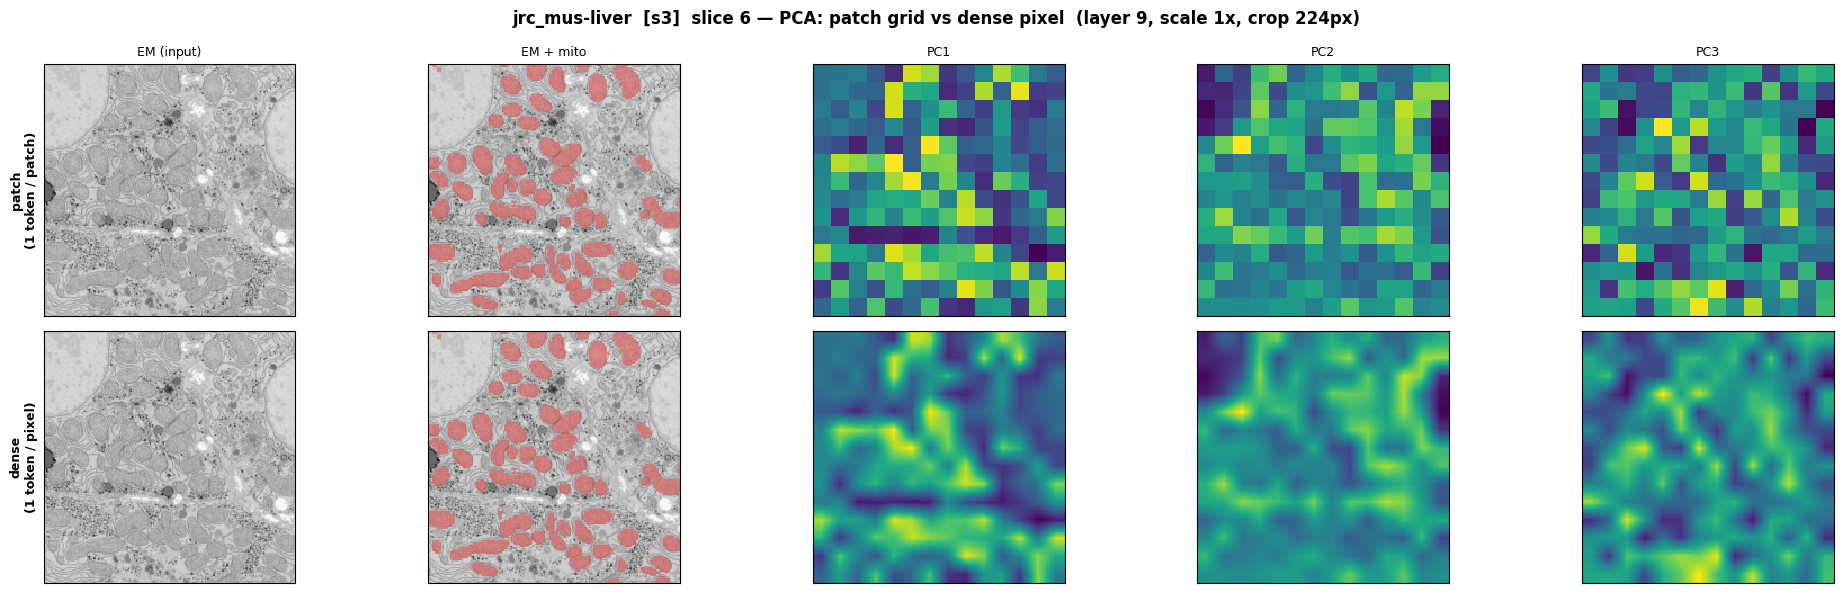

Figure saved to ../outputs/task2/task2_dense_pca_jrc_mus-liver_s3_slice6_layer9_scale1_crop224.png


In [9]:
# Project dense grid through the patch-level PCA (same transform, higher resolution)
dg = dense_grids[SLICE_IDX]          # (H, W, D)
H, W, D = dg.shape

dense_proj   = pca.transform(dg.reshape(-1, D))   # (H*W, 3)
dense_pc_maps = [minmax(dense_proj[:, c]).reshape(H, W) for c in range(3)]

model_input = np.array(_em_to_rgb(em[SLICE_IDX]))
mito_overlay = (
    make_overlay(model_input, _prepare_mito(mito[SLICE_IDX], em[SLICE_IDX]))
    if mito is not None else np.zeros_like(model_input)
)

# ── 2-row comparison: patch resolution (top) vs pixel resolution (bottom) ─────
# Columns: EM | EM+mito | PC1 | PC2 | PC3
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
fig.suptitle(
    f"{DATASET}  [{SCALE}]  slice {SLICE_IDX} — PCA: patch grid vs dense pixel  "
    f"(layer {LAYER_IDX}, scale {IMG_SCALE}x"
    + (f", crop {CROP_SIZE}px)" if CENTER_CROP else ")"),
    fontsize=12, fontweight="bold"
)

col_titles = ["EM (input)", "EM + mito", "PC1", "PC2", "PC3"]
row_labels = ["patch\n(1 token / patch)", "dense\n(1 token / pixel)"]
for row, (pc_row, label) in enumerate(zip([pc_maps, dense_pc_maps], row_labels)):
    axes[row, 0].imshow(model_input, interpolation="nearest")
    axes[row, 1].imshow(mito_overlay, interpolation="nearest")
    for c in range(3):
        axes[row, c + 2].imshow(pc_row[c], cmap="viridis", interpolation="nearest")
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight="bold")
    for col, ax in enumerate(axes[row]):
        ax.set_title(col_titles[col] if row == 0 else "", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
out_dir = Path("../outputs/task2")
out_dir.mkdir(parents=True, exist_ok=True)
crop_tag = f"_crop{CROP_SIZE}" if CENTER_CROP else ""
fname = out_dir / f"task2_dense_pca_{DATASET}_{SCALE}_slice{SLICE_IDX}_layer{LAYER_IDX}_scale{IMG_SCALE}{crop_tag}.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {fname}")
